# SWOT along-track slope wavenumber spectra:

This notebook takes the outputs of `compute_pass_slope()` and `compute_swath_slope_spectra()` (from `swot_alongtrack_slope.py`) -- a dict with one `PassSpectrumResult` per swath, each holding a list of per-segment `SegmentSpectrum` objects -- and:

1. Packs **all retained segments** (both swaths) into a single tidy `xarray.Dataset`, keeping each segment's mean/min/max latitude as coordinates/data variables.
2. Plots the **pass-mean PSD** per swath.
3. Plots **all individual segment PSDs**, colour-coded by latitude, to see how the spectrum varies along the pass.


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from swot_analysis.swot_alongtrack_spectra import load_swot_l2, compute_pass_spectra
from swot_analysis import plotting
from swot_analysis.swot_alongtrack_slope import compute_pass_slope, compute_swath_slope_spectrum

## 1. Load data and compute spectra

Edit `FILEPATH` and the segment-length / overlap parameters as needed.

In [2]:
data_dir = '/Users/zoecas/Documents/data/'
file = "SWOT_L2_LR_SSH_Expert_045_216_20260131T225821_20260131T234949_PID0_01.nc"
data = load_swot_l2(data_dir+file, ssh_var="ssha_karin_2")

SEGMENT_LENGTH_KM = 250.0
OVERLAP = 0.5
MAX_GAP_FRACTION = 0.25
MIN_GAP_RUN_KM = 10.0
out = compute_pass_slope(
        ssha=data["ssha"],
        latitude=data["latitude"],
        longitude=data["longitude"],
        cross_track_distance=data["cross_track_distance"],
        segment_length_km=SEGMENT_LENGTH_KM,
        overlap=OVERLAP,
        max_gap_fraction=MAX_GAP_FRACTION,
        min_gap_run_km=MIN_GAP_RUN_KM,
    )
for swath_name, res in out.items():
        segs = res["segments"]
        print(f"[{swath_name}] {len(segs)} segments with usable slope statistics")
        for seg in segs:
            print(f"   seg {seg.segment_index:3d}  lat {seg.lat_min:6.2f}..{seg.lat_max:6.2f}  "
                  f"n_pixels={seg.n_pixels_used}  slope_rms={seg.slope_rms:.3e}  "
                  f"v_rms={seg.geostrophic_velocity_rms}")


[left] 66 segments with usable slope statistics
   seg  52  lat  27.77.. 30.08  n_pixels=27  slope_rms=2.787e-06  v_rms=0.38722910322601306
   seg  53  lat  26.67.. 28.96  n_pixels=27  slope_rms=3.310e-06  v_rms=0.48086388130607527
   seg  54  lat  25.55.. 27.86  n_pixels=27  slope_rms=3.807e-06  v_rms=0.5693647274134354
   seg  55  lat  24.45.. 26.75  n_pixels=27  slope_rms=3.642e-06  v_rms=0.5692496866302497
   seg  56  lat  23.34.. 25.63  n_pixels=27  slope_rms=3.812e-06  v_rms=0.6203785803700734
   seg  57  lat  22.24.. 24.53  n_pixels=27  slope_rms=4.305e-06  v_rms=0.7318529972482883
   seg  58  lat  21.13.. 23.42  n_pixels=27  slope_rms=4.588e-06  v_rms=0.8106202441017101
   seg  59  lat  20.01.. 22.32  n_pixels=27  slope_rms=3.589e-06  v_rms=0.6554309429766172
   seg  60  lat  18.91.. 21.21  n_pixels=27  slope_rms=2.340e-06  v_rms=0.4593383709636208
   seg  61  lat  17.80.. 20.09  n_pixels=27  slope_rms=2.638e-06  v_rms=0.5495678128582775
   seg  62  lat  16.69.. 18.98  n_pixels

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_11017/169863289.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  sm = ax.pcolormesh(out['left']['field'].longitude,out['left']['field'].latitude,out['left']['field'].slope,vmax=1e-5,vmin=-1e-5,cmap='coolwarm')
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_11017/169863289.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(out['right']['field'].longitude,out['right']['field'].latitude,out['right']['field'].slope,vmax=1e-5,vmin=-1e-5,cmap='coolwarm')


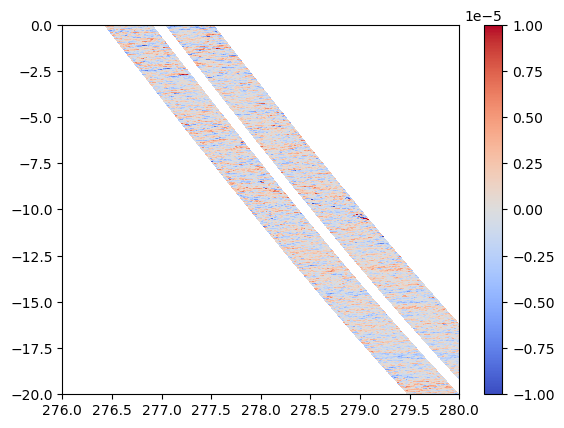

In [3]:

fig,ax = plt.subplots()
sm = ax.pcolormesh(out['left']['field'].longitude,out['left']['field'].latitude,out['left']['field'].slope,vmax=1e-5,vmin=-1e-5,cmap='coolwarm')
ax.pcolormesh(out['right']['field'].longitude,out['right']['field'].latitude,out['right']['field'].slope,vmax=1e-5,vmin=-1e-5,cmap='coolwarm')
ax.set_xlim(276,280);ax.set_ylim(-20,0);
plt.colorbar(sm,ax=ax)

## Compute slope spectra

In [4]:
spectra_left = compute_swath_slope_spectrum(
    slope_result =out["left"]['field'],
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
    detrend = "linear",
    window = "hann",
    min_pixels_per_segment = 3,
)

spectra_right = compute_swath_slope_spectrum(
    slope_result =out["right"]['field'],
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
    detrend = "linear",
    window = "hann",
    min_pixels_per_segment = 3,
)

In [5]:
def segments_to_dataset(spectra: dict) -> xr.Dataset:
    """
    Convert the dict-of-PassSpectrumResult returned by compute_pass_spectra()
    into a single xarray.Dataset stacking every retained segment (both
    swaths) along a `segment` dimension.

    Assumes all segments share the same wavenumber axis (true by
    construction in compute_swath_spectra, since every segment is
    resampled to the same `nperseg`).
    """
    all_segments = spectra.segments
    #wavenumber = None
    wavenumber = spectra.wavenumber
    #all_segments.extend(spectra.segments)

    if not all_segments:
        raise ValueError("No segments were retained for either swath; "
                          "nothing to put in a Dataset.")

    psd = np.stack([s.psd for s in all_segments], axis=0)  # (segment, wavenumber)

    ds = xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) power spectral density",
                  "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments],
                      {"long_name": "Segment mean latitude", "units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min for s in all_segments],
                     {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max for s in all_segments],
                     {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments],
                      {"long_name": "Segment mean longitude", "units": "degrees_east"}),
            along_track_distance_start_km=(["segment"],
                [s.along_track_distance_start_km for s in all_segments], {"units": "km"}),
            along_track_distance_end_km=(["segment"],
                [s.along_track_distance_end_km for s in all_segments], {"units": "km"}),
            n_pixels_used=(["segment"], [s.n_pixels_used for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            gap_filled=(["segment"], [bool(s.gap_filled) for s in all_segments]),
            swath=(["segment"], [s.swath for s in all_segments]),
            segment_index=(["segment"], [s.segment_index for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber,
                        {"long_name": "Along-track wavenumber", "units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
        attrs=dict(
            description="Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 LR Expert, "
                         "computed with compute_pass_spectra().",
        ),
    )
    return ds


ds_segments = xr.concat([segments_to_dataset(spectra_left),segments_to_dataset(spectra_right)],dim='segment')
ds_segments = ds_segments.assign_coords({'segment':np.arange(ds_segments.segment.size)})
ds_segments

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_11017/295306275.py:58: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'wavenumber' ('wavenumber',) The recommendation is to set join explicitly for this case.
  ds_segments = xr.concat([segments_to_dataset(spectra_left),segments_to_dataset(spectra_right)],dim='segment')


<xarray.Dataset> Size: 68kB
Dimensions:                        (segment: 61, wavenumber: 125)
Coordinates:
  * segment                        (segment) int64 488B 0 1 2 3 ... 57 58 59 60
  * wavenumber                     (wavenumber) float64 1kB 0.0 ... 0.2479
Data variables:
    psd                            (segment, wavenumber) float64 61kB 4.091e-...
    lat_mean                       (segment) float64 488B 28.92 26.7 ... -59.36
    lat_min                        (segment) float64 488B 27.77 25.55 ... -60.52
    lat_max                        (segment) float64 488B 30.08 27.86 ... -58.21
    lon_mean                       (segment) float64 488B 272.5 273.0 ... 293.6
    along_track_distance_start_km  (segment) float64 488B 6.5e+03 ... 1.65e+04
    along_track_distance_end_km    (segment) float64 488B 6.749e+03 ... 1.675...
    n_pixels_used                  (segment) int64 488B 27 27 27 27 ... 26 8 27
    valid_fraction                 (segment) float64 488B 0.7941 ... 0.7714
    gap_filled                     (segment) bool 61B False False ... True False
    swath                          (segment) <U5 1kB 'left' 'left' ... 'right'
    segment_index                  (segment) int64 488B 52 54 55 ... 115 117 132
Attributes:
    description:  Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 ...

In [6]:
def mean_spectra_to_dataset(spectra: dict, swath_name: str) -> xr.Dataset:
    """Pack the pass-mean PSD of each swath into a (swath, wavenumber) Dataset."""
    swath_names = [swath_name]
    wavenumber = spectra.wavenumber
    mean_psd = np.stack([spectra.mean_psd], axis=0)
    n_used = [spectra.n_segments_used]
    n_total = [spectra.n_segments_total]

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(["swath","wavenumber"], mean_psd,
                      {"long_name": "Pass-mean along-track SSH(A) PSD",
                       "units": "m^2 / (cycles/km)"}),
            n_segments_used=(["swath"], n_used),
            n_segments_total=(["swath"], n_total),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            swath=("swath", swath_names),
        ),
    )


ds_mean = xr.concat([mean_spectra_to_dataset(spectra_left,swath_name='left'),
                     mean_spectra_to_dataset(spectra_right,swath_name='right')],dim='swath')
ds_mean

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_11017/3438939840.py:24: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'wavenumber' ('wavenumber',) The recommendation is to set join explicitly for this case.
  ds_mean = xr.concat([mean_spectra_to_dataset(spectra_left,swath_name='left'),


<xarray.Dataset> Size: 3kB
Dimensions:           (swath: 2, wavenumber: 125)
Coordinates:
  * swath             (swath) <U5 40B 'left' 'right'
  * wavenumber        (wavenumber) float64 1kB 0.0 0.003998 ... 0.2479 0.2479
Data variables:
    mean_psd          (swath, wavenumber) float64 2kB 1.906e-11 nan ... nan
    n_segments_used   (swath) int64 16B 30 31
    n_segments_total  (swath) int64 16B 156 156

## Figures

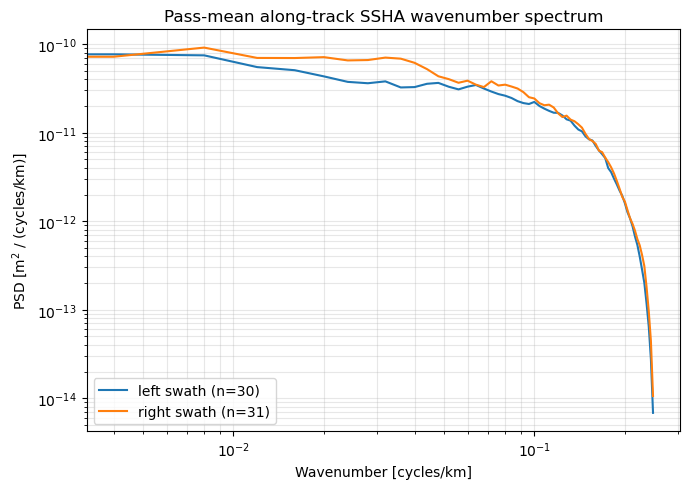

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

for swath_name in ds_mean.swath.values:
    da = ds_mean["mean_psd"].sel(swath=swath_name).dropna('wavenumber')
    ax.loglog(da.wavenumber, da, label=f"{swath_name} swath "
              f"(n={int(ds_mean['n_segments_used'].sel(swath=swath_name))})")

# reference power-law slopes for visual comparison (anchored at the
# lowest-wavenumber point of the first swath's spectrum)
k_ref = ds_mean.wavenumber.values[1:]
psd_ref = ds_mean["mean_psd"].isel(swath=0).values[1]
k0 = ds_mean.wavenumber.values[1]
#for exponent, style in [(-2, "--"), (-11/3, ":")]:
#    ax.loglog(k_ref, psd_ref * (k_ref / k0) ** exponent, style, color="gray",
#              label=f"$k^{{{exponent:.0f}}}$".replace("-4", "-11/3"))

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("Pass-mean along-track SSHA wavenumber spectrum")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

Text(0.5, 0.98, 'Per-segment along-track SSHA wavenumber spectra')

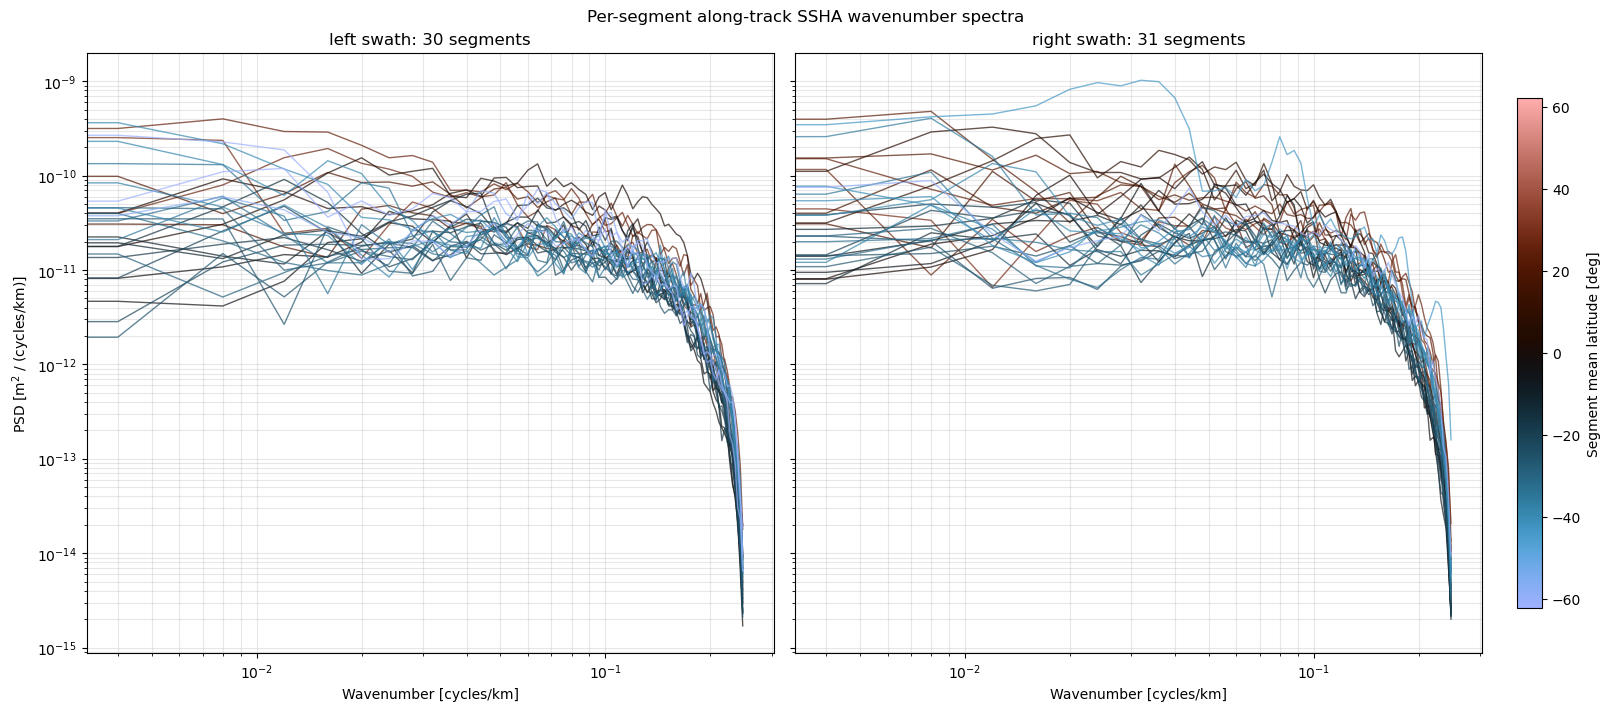

In [8]:
swath_names = list(np.unique(ds_segments["swath"].values))
fig, axes = plt.subplots(1, len(swath_names), figsize=(8 * len(swath_names), 7), sharey=True, layout='constrained')
if len(swath_names) == 1:
    axes = [axes]

cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

for ax, swath_name in zip(axes, swath_names):
    sub = ds_segments.where(ds_segments["swath"] == swath_name, drop=True)
    for i in range(sub.sizes["segment"]):
        seg = sub.isel(segment=i).dropna('wavenumber')
        ax.loglog(seg.wavenumber, seg["psd"],
                  color=cmap(norm(float(seg["lat_mean"]))), alpha=0.7, lw=1)
    ax.set_title(f"{swath_name} swath: {sub.sizes['segment']} segments")
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("PSD [m$^2$ / (cycles/km)]")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.85, pad=0.05)
cbar.set_label("Segment mean latitude [deg]")

fig.suptitle("Per-segment along-track SSHA wavenumber spectra")
#fig.tight_layout(rect=[0, 0, 0.93, 0.95])

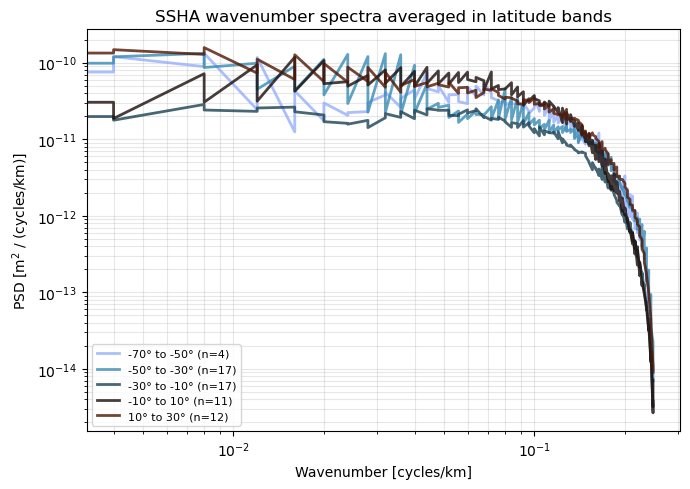

In [9]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range
#LAT_BIN_EDGES = [-70,-40,-10,0,10,40,71]

fig, ax = plt.subplots(figsize=(7, 5))
cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

binned = ds_segments.groupby_bins("lat_mean", LAT_BIN_EDGES)

for lat_bin, group in binned:
    if group.sizes["segment"] == 0:
        continue
    mean_psd = group["psd"].mean(dim="segment").dropna('wavenumber')
    bin_center = 0.5 * (lat_bin.left + lat_bin.right)
    #ax.loglog(group.wavenumber, mean_psd,
    #          label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° "
    #                f"(n={group.sizes['segment']})")
    ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2., alpha=.8,
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("SSHA wavenumber spectra averaged in latitude bands")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

Text(0.5, 0.98, 'Per-segment SSHA spectra (alpha-blended) with latitude-binned means overlaid')

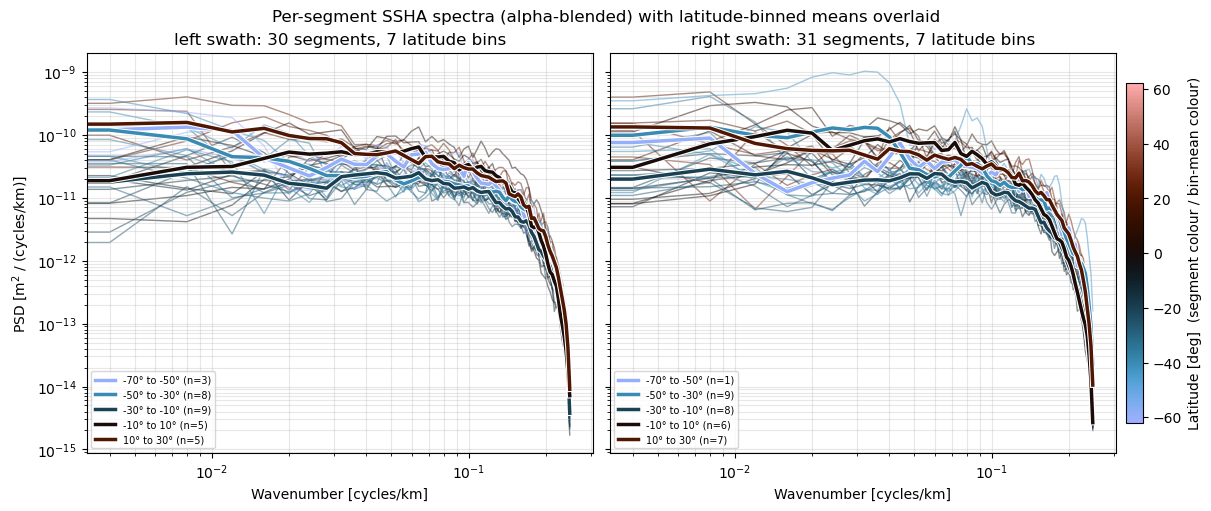

In [12]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range

swath_names = list(np.unique(ds_segments["swath"].values))
fig, axes = plt.subplots(1, len(swath_names), figsize=(6 * len(swath_names), 5), sharey=True,layout='constrained')
if len(swath_names) == 1:
    axes = [axes]

# shared colormap/normalisation for BOTH the per-segment lines and the
# latitude-binned mean lines, so colours are directly comparable
cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

for ax, swath_name in zip(axes, swath_names):
    sub = ds_segments.where(ds_segments["swath"] == swath_name, drop=True)

    # -- layer 1: all individual segments, thin + alpha-blended --
    for i in range(sub.sizes["segment"]):
        seg = sub.isel(segment=i).dropna('wavenumber')
        ax.loglog(seg.wavenumber, seg["psd"],
                  color=cmap(norm(float(seg["lat_mean"]))), alpha=0.5, lw=1, zorder=1)

    # -- layer 2: latitude-binned mean spectra, drawn on top --
    binned = sub.groupby_bins("lat_mean", LAT_BIN_EDGES)
    for lat_bin, group in binned:
        if group.sizes["segment"] == 0:
            continue
        group = group.dropna('wavenumber')
        mean_psd = group["psd"].mean(dim="segment")
        bin_center = 0.5 * (lat_bin.left + lat_bin.right)
        ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2.5, alpha=1.0,
                  path_effects=[pe.Stroke(linewidth=4, foreground="white"), pe.Normal()],
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

    ax.set_title(f"{swath_name} swath: {sub.sizes['segment']} segments, "
                 f"{len(LAT_BIN_EDGES) - 1} latitude bins")
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left")

axes[0].set_ylabel("PSD [m$^2$ / (cycles/km)]")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.85, pad=0.02)
cbar.set_label("Latitude [deg]  (segment colour / bin-mean colour)")

fig.suptitle("Per-segment SSHA spectra (alpha-blended) with latitude-binned means overlaid")
#fig.tight_layout(rect=[0, 0, 0.93, 0.95])